In [1]:
import pandas as pd
import concurrent.futures
import multiprocessing
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file_path = "/content/sen.csv"

In [3]:
chunk_size = 100000

In [4]:
df_sample = pd.read_csv(file_path, nrows=1)
column_names = df_sample.columns.tolist()

In [5]:
with open(file_path, 'r') as file:
    total_rows = sum(1 for _ in file) - 1

In [6]:
start_rows = list(range(1, total_rows, chunk_size))

# Multithreading

In [7]:
def read_csv_chunk(start_row):
    return pd.read_csv(file_path, skiprows=start_row, nrows=chunk_size, names=column_names, header=None)

In [8]:
with concurrent.futures.ThreadPoolExecutor() as executor:
    df_chunks = list(executor.map(read_csv_chunk, start_rows))

In [9]:
df = pd.concat(df_chunks, ignore_index=True)

In [10]:
print(f"✅ Loaded {df.shape[0]:,} rows using Multithreading.")

✅ Loaded 257,004 rows using Multithreading.


# DATA CLEANING & PREPROCESSING

In [11]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [12]:
import time
import timeit
from scipy.stats import mode

In [13]:
# mean_value = df.mean(numeric_only=True)
# median_value = df.median(numeric_only=True)
# mode_value = df.mode(numeric_only=True).iloc[0]
# print("\n🔹 **Data Statistics:**")
# print(f"Mean:\n{mean_value}\n")
# print(f"Median:\n{median_value}\n")
# print(f"Mode:\n{mode_value}\n")

In [14]:
import numpy as np
from numba import jit

In [15]:
# start_time = time.perf_counter()


# mean_value = df.select_dtypes(include=[np.number]).mean()
# median_value = df.select_dtypes(include=[np.number]).median()
# mode_value = df.mode(numeric_only=True).iloc[0].to_numpy()

# execution_time = time.perf_counter() - start_time

# print("\n🔹 **Data Statistics:**")
# print(f"Mean:\n{mean_value}\n")
# print(f"Median:\n{median_value}\n")
# print(f"Mode:\n{mode_value}\n")
# print(f"⏳ Execution Time: {execution_time:.6f} seconds")

In [16]:
import time
import polars as pl
import numpy as np

In [17]:
# start_time = time.perf_counter_ns()

# mean_value = df.mean()
# median_value = df.median()

# mode_value = np.array([np.bincount(df[col].to_numpy().astype(int)).argmax() for col in df.columns])

# execution_time = (time.perf_counter_ns() - start_time) / 1e6  # Convert ns to ms
# print("\n🔹 **Data Statistics:**")
# print(f"Mean:\n{mean_value}\n")
# print(f"Median:\n{median_value}\n")
# print(f"Mode:\n{mode_value}\n")
# print(f"⏳ Execution Time: {execution_time:.3f} ms")

In [18]:
# start_time = time.perf_counter_ns()

# mean_value = df.mean()
# median_value = df.median()


# mode_value = {col: np.bincount(df[col].to_numpy().astype(int)).argmax() for col in df.columns}

# execution_time = (time.perf_counter_ns() - start_time) / 1e6  # Convert ns to ms

# print("\n🔹 **Data Statistics:**")
# print(f"Mean:\n{mean_value}\n")
# print(f"Median:\n{median_value}\n")
# print(f"Mode:\n{mode_value}\n")
# print(f"⏳ Execution Time: {execution_time:.3f} ms")

In [19]:
start_time = time.perf_counter_ns()

mean_value = df.mean()
median_value = df.median()


mode_value = {col: np.bincount(df[col].to_numpy().astype(int)).argmax() for col in df.columns}

execution_time_ms = (time.perf_counter_ns() - start_time) / 1e6
execution_time_sec = execution_time_ms / 1000  # Convert ms to sec

print("\n🔹 **Data Statistics:**")
print(f"Mean:\n{mean_value}\n")
print(f"Median:\n{median_value}\n")
print(f"Mode:\n{mode_value}\n")
print(f"⏳ Execution Time: {execution_time_ms:.3f} ms ({execution_time_sec:.6f} sec)")


🔹 **Data Statistics:**
Mean:
sensor_id              250.049890
sensor_reading          99.981659
control_value           50.008288
temperature             24.996109
pressure              1013.034305
humidity                50.017473
performance_metric     149.989946
env_index              328.913975
adjusted_sensor        149.981711
dtype: float64

Median:
sensor_id              250.000
sensor_reading         100.000
control_value           50.000
temperature             24.990
pressure              1013.030
humidity                49.970
performance_metric     149.940
env_index              328.905
adjusted_sensor        149.644
dtype: float64

Mode:
{'sensor_id': 230, 'sensor_reading': 100, 'control_value': 49, 'temperature': 24, 'pressure': 1013, 'humidity': 28, 'performance_metric': 149, 'env_index': 329, 'adjusted_sensor': 148}

⏳ Execution Time: 66.244 ms (0.066244 sec)


In [20]:
if "sensor_reading" not in df.columns:
    raise KeyError("The column 'sensor_reading' is missing in the dataset.")

# PARALLEL COMPUTATION (MULTIPROCESSING)

In [21]:
def process_chunk(chunk):
    chunk["adjusted_value"] = chunk["sensor_reading"] * 1.05
    return chunk

In [22]:
num_cores = multiprocessing.cpu_count()
df_split = [df.iloc[i::num_cores] for i in range(num_cores)]

In [23]:
with multiprocessing.Pool(num_cores) as pool:
    df_processed_chunks = pool.map(process_chunk, df_split)

/usr/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The most likely reason you are seeing this error is because you are using the
multiprocessing module on Linux, which uses fork() by default. This will be
fixed in Python 3.14. Until then, you want to use the "spawn" context instead.

See https://docs.pola.rs/user-guide/misc/multiprocessing/ for details.

  self.pid = os.fork()


In [24]:
df_final = pd.concat(df_processed_chunks, ignore_index=True)

In [25]:
print(f"✅ Processed {df_final.shape[0]:,} rows using Multiprocessing.")

✅ Processed 257,004 rows using Multiprocessing.


# DATA VISUALIZATION

In [26]:
sns.set(style="whitegrid")

# Histogram

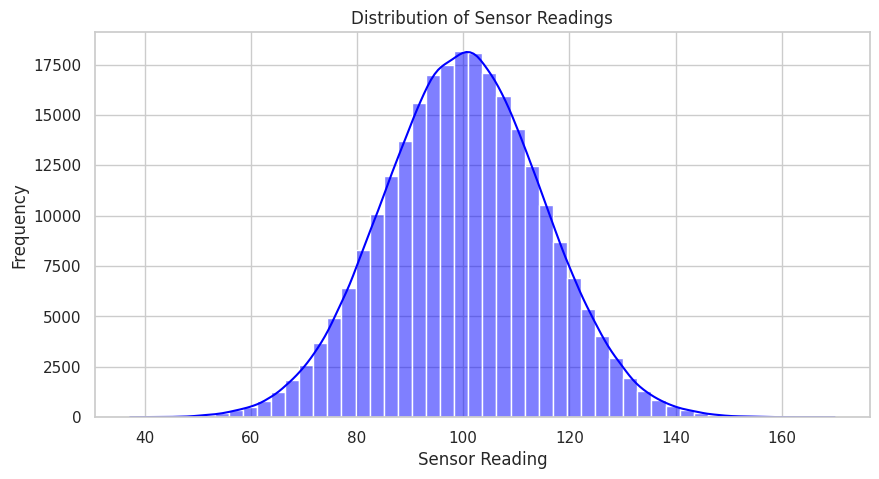

In [27]:
plt.figure(figsize=(10, 5))
sns.histplot(df_final["sensor_reading"], bins=50, kde=True, color="blue")
plt.title("Distribution of Sensor Readings")
plt.xlabel("Sensor Reading")
plt.ylabel("Frequency")
plt.show()

# Boxplot to check outliers

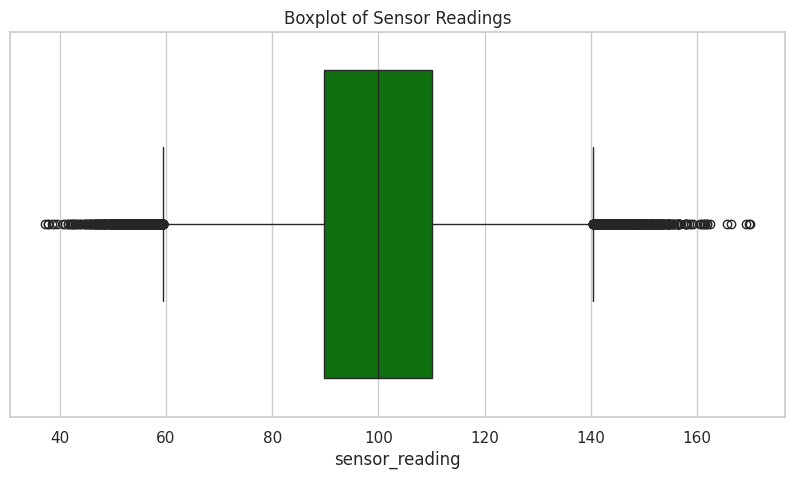

In [28]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_final["sensor_reading"], color="green")
plt.title("Boxplot of Sensor Readings")
plt.show()

# Line plot

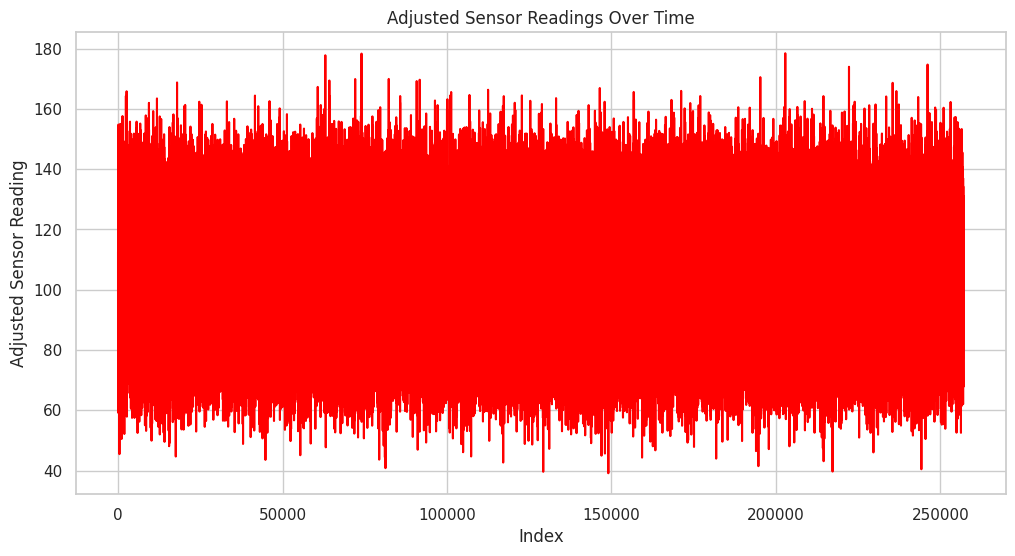

In [29]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=range(len(df_final)), y=df_final["adjusted_value"], color="red")
plt.title("Adjusted Sensor Readings Over Time")
plt.xlabel("Index")
plt.ylabel("Adjusted Sensor Reading")
plt.show()

In [30]:
import time

total_start_time = time.perf_counter_ns()

total_execution_time_ns = time.perf_counter_ns() - total_start_time
total_execution_time_ms = total_execution_time_ns / 1e6
total_execution_time_sec = total_execution_time_ms / 1000

# Print Total Execution Time
print(f"\n⏳ **Total Execution Time:** {total_execution_time_ms:.3f} ms ({total_execution_time_sec:.6f} sec)")



⏳ **Total Execution Time:** 0.061 ms (0.000061 sec)
